## Loading packages

In [1]:
import scanpy as sc 
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA

import scipy.sparse as sp 
import warnings
import os
import sys

warnings.filterwarnings("ignore")

os.environ["R_HOME"] = "/home/bio/miniconda3/envs/spCLUE/lib/R"
# os.environ["R_HOME"] = "/home/lxx/.conda/envs/r4Base/lib/R"
# os.environ["R_USER"] = "/home/lxx/.local/lib/python3.9/site-packages/rpy2"
spCLUE_ROOT_PATH = "/home/bio/lhz/spCLUE"
sys.path.append(spCLUE_ROOT_PATH)
import spCLUE

spCLUE.fix_seed(0)

/home/bio/miniconda3/envs/spCLUE/lib/python3.9/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## Loading data

In [2]:
sample_name="151671"
# ========== 1. 处理数据 ==========
adata = spCLUE.preprocess_data(input_dir="../dataset/DLPFC/151671/")


[预处理开始] ---------------->
========== 路径二: 标准全基因预处理 (规范化 -> Log 转换 -> 缩放) ==========
✅ 完成规范化、Log 转换和 Z-score 缩放。

✅ 最终数据状态：
AnnData object with n_obs × n_vars = 4110 × 21631
    obs: 'in_tissue', 'array_row', 'array_col', 'Region', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_counts', 'mean', 'std'
    uns: 'spatial', 'log1p'
    obsm: 'spatial'
    layers: 'counts'
obs (前5行):                     in_tissue  array_row  array_col  Region  n_counts
AAACAAGTATCTCCCA-1          1         50        102  Layer5    9080.0
AAACACCAATAACTGC-1          1         59         19  Layer6    6183.0
AAACAGAGCGACTCCT-1          1         14         94  Layer3    6273.0
AAACAGCTTTCAGAAG-1          1         43          9  Layer5    7015.0
AAACAGGGTCTATATT-1          1         47         13  Layer5    6991.0


🚀 开始分析边界效应...
📍 正在构建物理空间近邻图...
✅ 找到同层内部边 (Intra-layer): 11922 条
✅ 找到边界跨层边 (Inter-layer / Boundary): 586 条

⏳ 计算空间 1：全基因组特征...
⏳ 计算空间 2：Top 3000 高变基因...
⏳ 计算空间 3：HVG 3000 + PCA 200...

📊 正在生成对比图表...


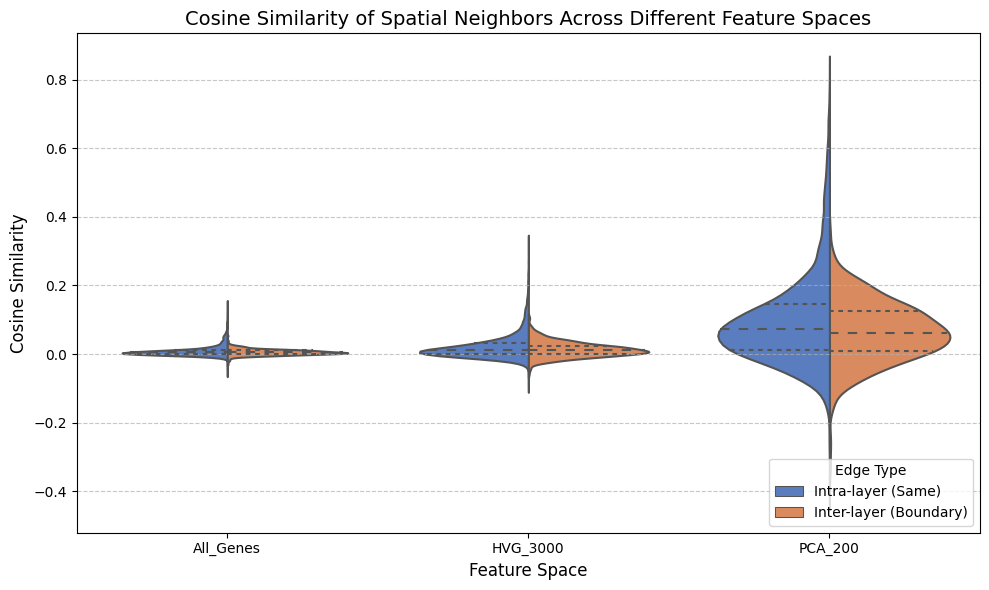


📈 平均余弦相似度统计：
[All_Genes ] 同层内部均值: 0.0086 | 边界跨层均值: 0.0056 | 区分度 (Gap): 0.0030
[ HVG_3000 ] 同层内部均值: 0.0210 | 边界跨层均值: 0.0133 | 区分度 (Gap): 0.0078
[ PCA_200  ] 同层内部均值: 0.0962 | 边界跨层均值: 0.0648 | 区分度 (Gap): 0.0313


In [7]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import paired_cosine_distances
import scipy.sparse as sp

def analyze_boundary_similarity(adata, label_col='Region'):
    print("🚀 开始分析边界效应...")
    
    # 1. 提取有效标签（剔除 NaN 的背景点）
    valid_mask = adata.obs[label_col].notna()
    adata_valid = adata[valid_mask].copy()
    labels = adata_valid.obs[label_col].values
    coords = adata_valid.obsm['spatial']
    
    # 2. 构建空间近邻图 (Visium 通常每个点有 6 个物理邻居，这里设 k=7 包含自己)
    print("📍 正在构建物理空间近邻图...")
    nbrs = NearestNeighbors(n_neighbors=7).fit(coords)
    _, indices = nbrs.kneighbors(coords)
    
    # 3. 区分“同层内部边”和“边界跨层边”
    intra_edges = []
    inter_edges = []
    
    for i in range(len(indices)):
        for j in indices[i][1:]: # 跳过自身 (index 0)
            if labels[i] == labels[j]:
                intra_edges.append((i, j))
            else:
                inter_edges.append((i, j))
                
    # 去除无向图中的重复边
    intra_edges = list(set([tuple(sorted(e)) for e in intra_edges]))
    inter_edges = list(set([tuple(sorted(e)) for e in inter_edges]))
    
    print(f"✅ 找到同层内部边 (Intra-layer): {len(intra_edges)} 条")
    print(f"✅ 找到边界跨层边 (Inter-layer / Boundary): {len(inter_edges)} 条")

    def get_sims(X):
        node_i_intra, node_j_intra = [e[0] for e in intra_edges], [e[1] for e in intra_edges]
        node_i_inter, node_j_inter = [e[0] for e in inter_edges], [e[1] for e in inter_edges]
        
        sim_intra = 1 - paired_cosine_distances(X[node_i_intra], X[node_j_intra])
        sim_inter = 1 - paired_cosine_distances(X[node_i_inter], X[node_j_inter])
        return sim_intra, sim_inter

    results = {}

    # ==========================================
    # 空间 1：特征空间 (Raw/Normalized)
    # ==========================================
    print("\n⏳ 计算空间 1：全基因组特征...")
    X_raw = adata_valid.X
    sim_intra_raw, sim_inter_raw = get_sims(X_raw)
    results['All_Genes'] = {'Intra': sim_intra_raw, 'Inter': sim_inter_raw}

    # ==========================================
    # 空间 2：Top 3000 高变基因 (HVG 3000)
    # ==========================================
    print("⏳ 计算空间 2：Top 3000 高变基因...")
    adata_hvg = adata_valid.copy()
    
    # 🔥 核心修复点：明确指定 layer="counts"
    # 如果没有 'counts' 层，自动退回使用普通 seurat flavor 以防报错
    if 'counts' in adata_hvg.layers:
        sc.pp.highly_variable_genes(adata_hvg, n_top_genes=3000, flavor='seurat_v3', layer='counts')
    else:
        sc.pp.highly_variable_genes(adata_hvg, n_top_genes=3000, flavor='seurat')
        
    X_hvg = adata_hvg[:, adata_hvg.var['highly_variable']].X
    sim_intra_hvg, sim_inter_hvg = get_sims(X_hvg)
    results['HVG_3000'] = {'Intra': sim_intra_hvg, 'Inter': sim_inter_hvg}

    # ==========================================
    # 空间 3：HVG 3000 + PCA 200
    # ==========================================
    print("⏳ 计算空间 3：HVG 3000 + PCA 200...")
    # 因为前面的 .X 已经做了标准化，这里直接跑 PCA 是完全合理的
    sc.pp.pca(adata_hvg, n_comps=200)
    X_pca = adata_hvg.obsm['X_pca']
    sim_intra_pca, sim_inter_pca = get_sims(X_pca)
    results['PCA_200'] = {'Intra': sim_intra_pca, 'Inter': sim_inter_pca}

    # ==========================================
    # 4. 可视化对比结果
    # ==========================================
    print("\n📊 正在生成对比图表...")
    plot_data = []
    for space_name, sims in results.items():
        plot_data.extend([{'Space': space_name, 'Edge Type': 'Intra-layer (Same)', 'Similarity': s} for s in sims['Intra']])
        plot_data.extend([{'Space': space_name, 'Edge Type': 'Inter-layer (Boundary)', 'Similarity': s} for s in sims['Inter']])
        
    df_plot = pd.DataFrame(plot_data)

    plt.figure(figsize=(10, 6))
    sns.violinplot(x='Space', y='Similarity', hue='Edge Type', data=df_plot, split=True, inner="quart", palette="muted")
    plt.title("Cosine Similarity of Spatial Neighbors Across Different Feature Spaces", fontsize=14)
    plt.ylabel("Cosine Similarity", fontsize=12)
    plt.xlabel("Feature Space", fontsize=12)
    plt.legend(title="Edge Type", loc='lower right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # 打印具体的均值数据
    print("\n📈 平均余弦相似度统计：")
    for space in ['All_Genes', 'HVG_3000', 'PCA_200']:
        mean_intra = results[space]['Intra'].mean()
        mean_inter = results[space]['Inter'].mean()
        gap = mean_intra - mean_inter
        print(f"[{space:^10}] 同层内部均值: {mean_intra:.4f} | 边界跨层均值: {mean_inter:.4f} | 区分度 (Gap): {gap:.4f}")

# 运行函数
analyze_boundary_similarity(adata, label_col='Region')